## Домашнее задание 5

Набор данных содержит информацию о трех разных типах вина в зависимости от ряда характеристик. Сегодня мы будем работать с этим датасетом, используя алгоритмы понижения размерности и машинного обучения.

Всего в датасете есть 13 характеристик: Alcohol,	Malic,	Ash,	Alcalinity,	Magnesium,	Phenols,	Flavanoids,	Nonflavanoids,	Proanthocyanins,	Color,	Hue,	Dilution,	Proline.

Давайте импортируем основные библиотеки, которые могут нам понадобиться в рамках работы над датасетом:

In [1]:
%%capture
!pip install catboost
!pip install opentsne
!pip install umap-learn

In [2]:
# Data manipulation
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
import plotly.express as px

# Data preprocessing
from sklearn.model_selection import train_test_split as tts

# Dimensionality Reduction
from openTSNE.sklearn import TSNE
import umap
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score

# tqdm
from tqdm.auto import tqdm

# warnings
import warnings
warnings.filterwarnings('ignore')


Импортируем датасет и посмотрим на его внутреннюю структуру:

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_05_visualization/wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 14)

В этом модуле мы будем заниматься практическим использованием методов понижения размерности. В этот раз в качестве зависимой переменной будем использовать переменную `type` — к какому типу относится наше вино.  

## Задание 1. Разведочный анализ данных (3 балла)

Воспользуйтесь графиком `sns.displot()` и постройте 13 графиков распределения разных переменных на одном поле subplots. Параметр hue возьмите равным `Type`. Напишите, какие выводы о различиях в типах вин можно сделать исходя из этих графиков.

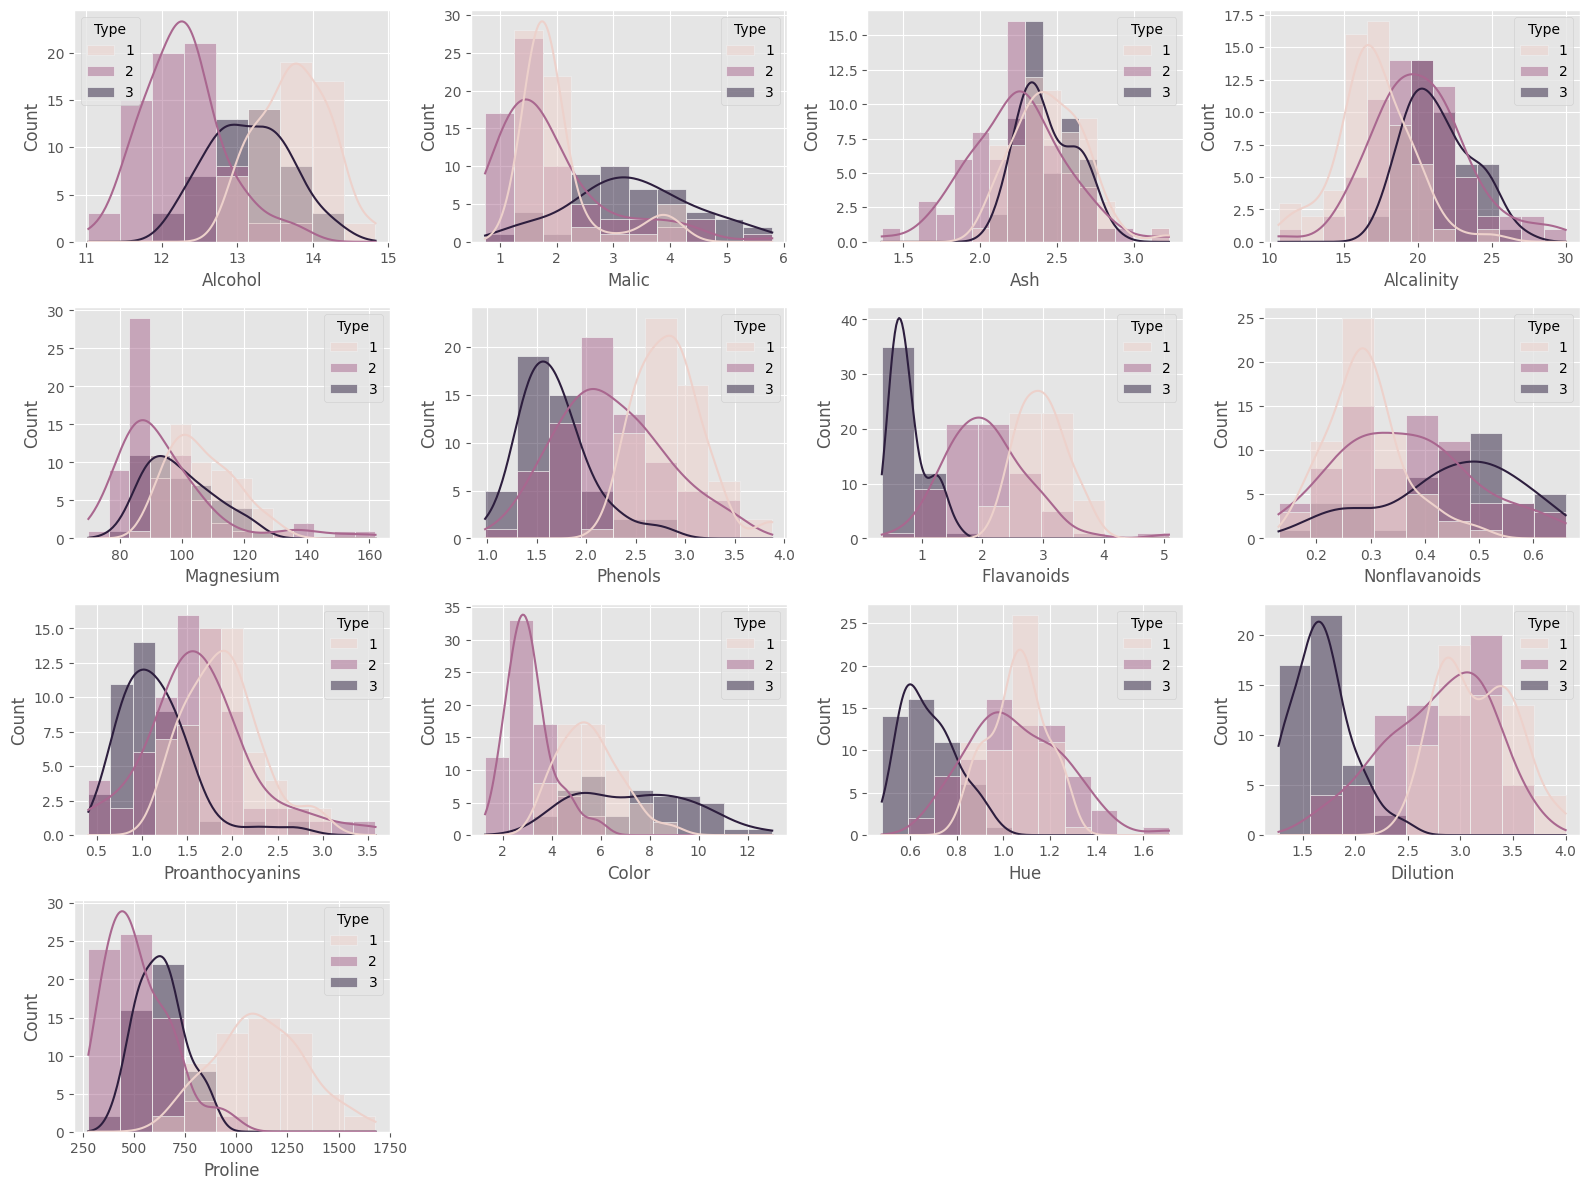

In [5]:
features = [col for col in df.columns if col != 'Type']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Type', kde=True, ax=axes[i])

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Задание 2. Есть ли корреляции? (1 балл)

Постройте `sns.heatmap` для всех числовых характеристик внутри датасета. Определите, какие три переменные больше всего коррелируют с типом вина. Добавьте стрелочки с текстом (функция `annotate`) с указанием на эти переменные.

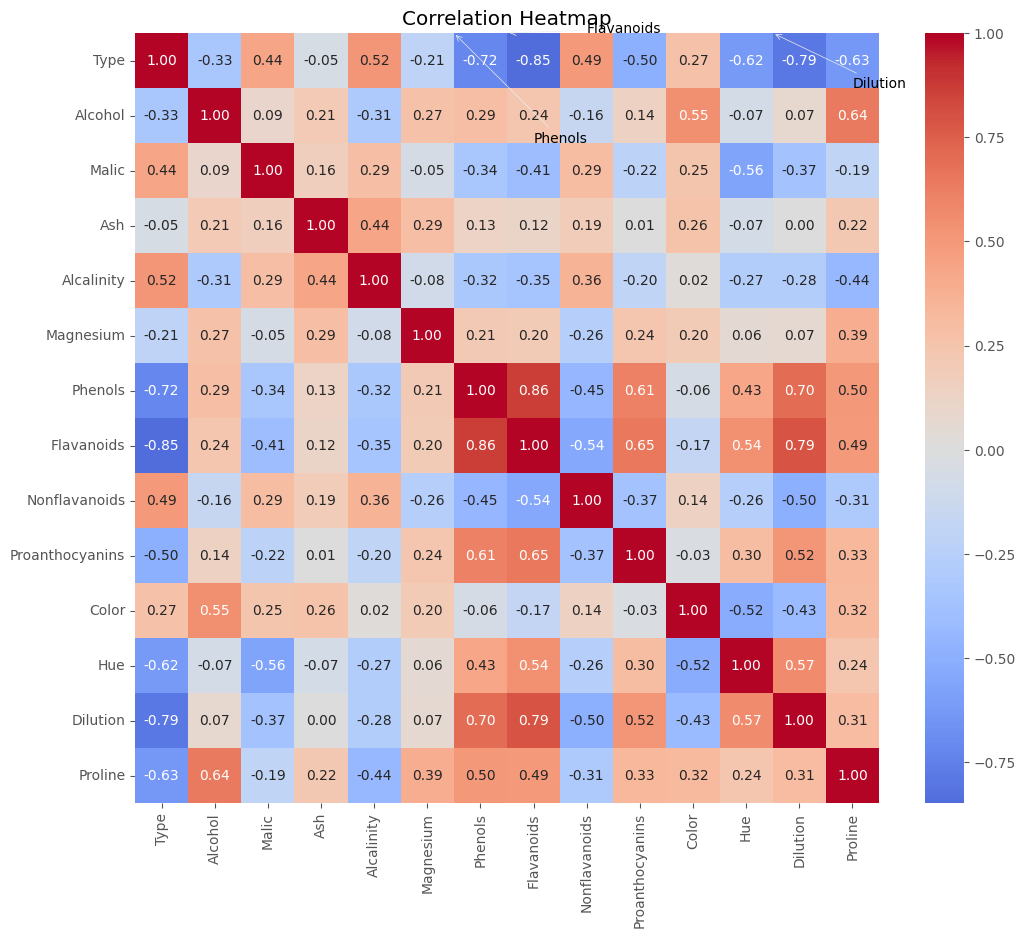

In [6]:
corr = df.corr()

plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

type_idx = corr.columns.get_loc('Type')

top_features = ['Flavanoids', 'Dilution', 'Phenols']

for i, feature in enumerate(top_features):
    x = corr.columns.get_loc(feature)

    ax.annotate(
        feature,
        xy=(x, type_idx),
        xytext=(x + 1.5, type_idx + i),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )

plt.title("Correlation Heatmap")
plt.show()

## Задание 3. Сохранение доли объясненной дисперсии в зависимости от `n_components` (3 балла)

Воспользуйтесь методом понижения размерности `PCA` с разным параметром n_components — от 1 до 10. Постройте линейный график совокупной объясненной дисперсии при добавлении каждой новой компоненты. Также на том же полотне постройте столбчатую диаграмму: каждый столбец должен показывать, сколько объясненной дисперсии вносит каждая следующая компонента (аналогичный пример разбирали на семинарском занятии).


In [7]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Type')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
explained_variance = []

for n in range(1, 11):
    pca = PCA(n_components=n)
    pca.fit(X_scaled)

    explained_variance.append(np.sum(pca.explained_variance_ratio_))

In [9]:
pca_full = PCA()
pca_full.fit(X_scaled)

individual_var = pca_full.explained_variance_ratio_

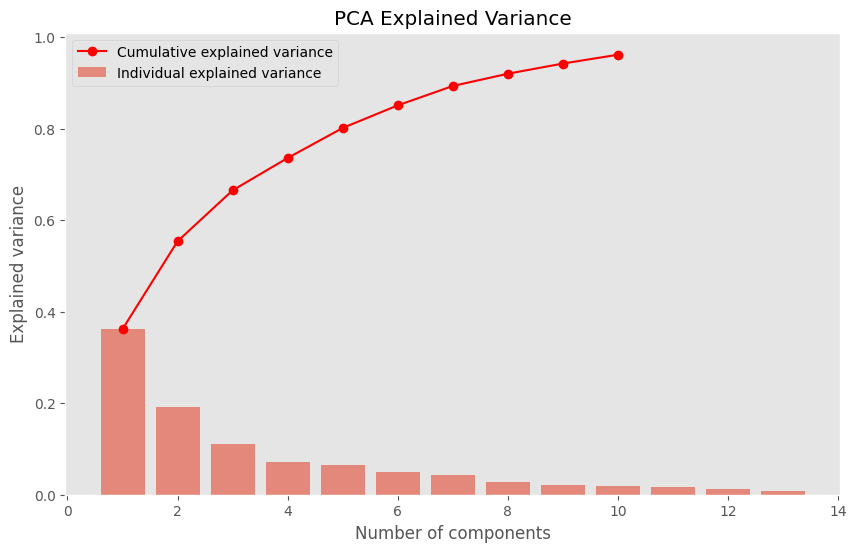

In [10]:
components = range(1, len(individual_var) + 1)

plt.figure(figsize=(10, 6))

plt.bar(components, individual_var, alpha=0.6, label='Individual explained variance')

plt.plot(range(1, 11), explained_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title('PCA Explained Variance')

plt.legend()
plt.grid()

plt.show()

## Задание 4. Сравнение результатов работы разных алгоритмов понижения размерности (4 балла)

Воспользуйтесь четырьмя любыми алгоритмами понижения размерности (n_components возьмите равным 2 или 3). Создайте поле с двумерными или трехмерными графиками, на которых будут отображены результаты работы каждого алгоритма, а цветом будет обозначен тип вина (наша зависимая переменная).

Зрительно сделайте вывод о том, какой метод отработал лучше. Опишите результаты и качественно обоснуйте ваш выбор лучшего алгоритма. Если невозможно выбрать лучший алгоритм, тоже обоснуйте почему.

In [11]:
from sklearn.manifold import Isomap

y = df['Type']

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
isomap = Isomap(n_components=2)
umap_model = umap.UMAP(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)
X_tsne = tsne.fit_transform(X_scaled)
X_isomap = isomap.fit_transform(X_scaled)
X_umap = umap_model.fit_transform(X_scaled)


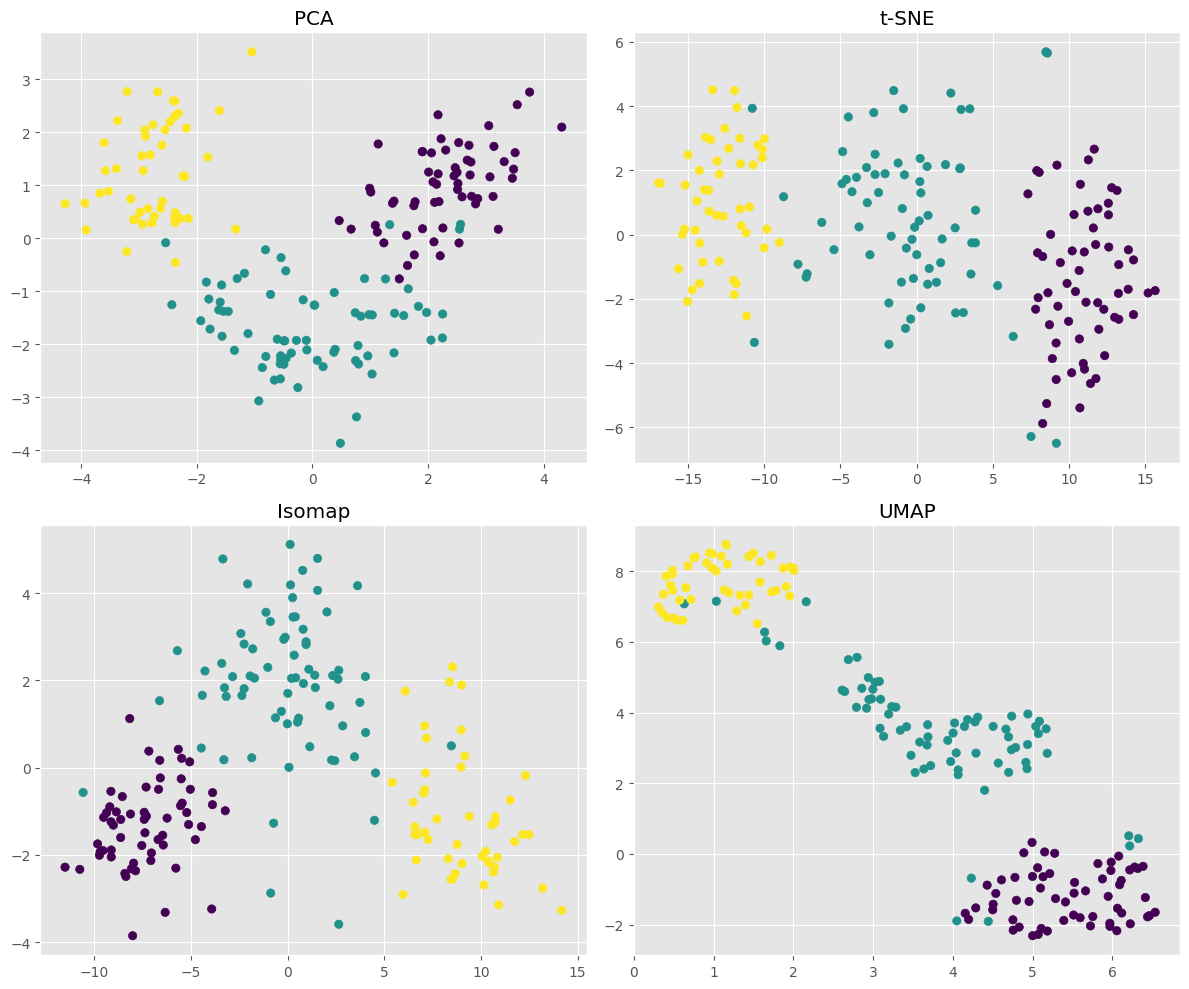

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

methods = {
    "PCA": X_pca,
    "t-SNE": X_tsne,
    "Isomap": X_isomap,
    "UMAP": X_umap
}

for ax, (name, X_transformed) in zip(axes.flatten(), methods.items()):
    scatter = ax.scatter(
        X_transformed[:, 0],
        X_transformed[:, 1],
        c=y,
        cmap='viridis'
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Выводы по задаче 4.
Все алгоритмы показала хорошее качество разделения данных. Лучшим можно считать t-SNE, так как кластеры наиболее компактны и хорошо отделены.

## Задание 5. Сравнение результатов работы алгоритмов (6 баллов)

Разделите выборку на обучающую и тестовую. Используйте два метода понижения размерности, которые лучше всего показали себя в предыдущем задании, а также исходные данные без понижения размерности. Примените 6 любых алгоритмов классификации на этих трех типах данных. Постройте два `sns.heatmap()` (для train и test), в каждом из них должно быть по 18 ячеек (6 алгоритмов х 3 вида данных) — в каждой ячейке должно быть указано значение `Accuracy` для определенного алгоритма с определенными данными. Аналогичную работу проделывали на семинаре.


Определите, какой алгоритм дал лучшие результаты, и опишите почему. Как алгоритмы отрабатывают при работе на данных без понижения размерности? В чем разница в полученных значениях?

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

umap_model = umap.UMAP(n_components=2, random_state=42)
X_train_umap = umap_model.fit_transform(X_train)
X_test_umap = umap_model.transform(X_test)

tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)
X_test_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_test)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "NaiveBayes": GaussianNB()
}

In [16]:
def evaluate(X_train, X_test, y_train, y_test):
    results_train = {}
    results_test = {}

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        results_train[name] = accuracy_score(y_train, y_pred_train)
        results_test[name] = accuracy_score(y_test, y_pred_test)

    return results_train, results_test

In [17]:
train_raw, test_raw = evaluate(X_train, X_test, y_train, y_test)

train_pca, test_pca = evaluate(X_train_pca, X_test_pca, y_train, y_test)

train_umap, test_umap = evaluate(X_train_umap, X_test_umap, y_train, y_test)

In [18]:
train_df = pd.DataFrame({
    "Raw": train_raw,
    "PCA": train_pca,
    "UMAP": train_umap
})

test_df = pd.DataFrame({
    "Raw": test_raw,
    "PCA": test_pca,
    "UMAP": test_umap
})

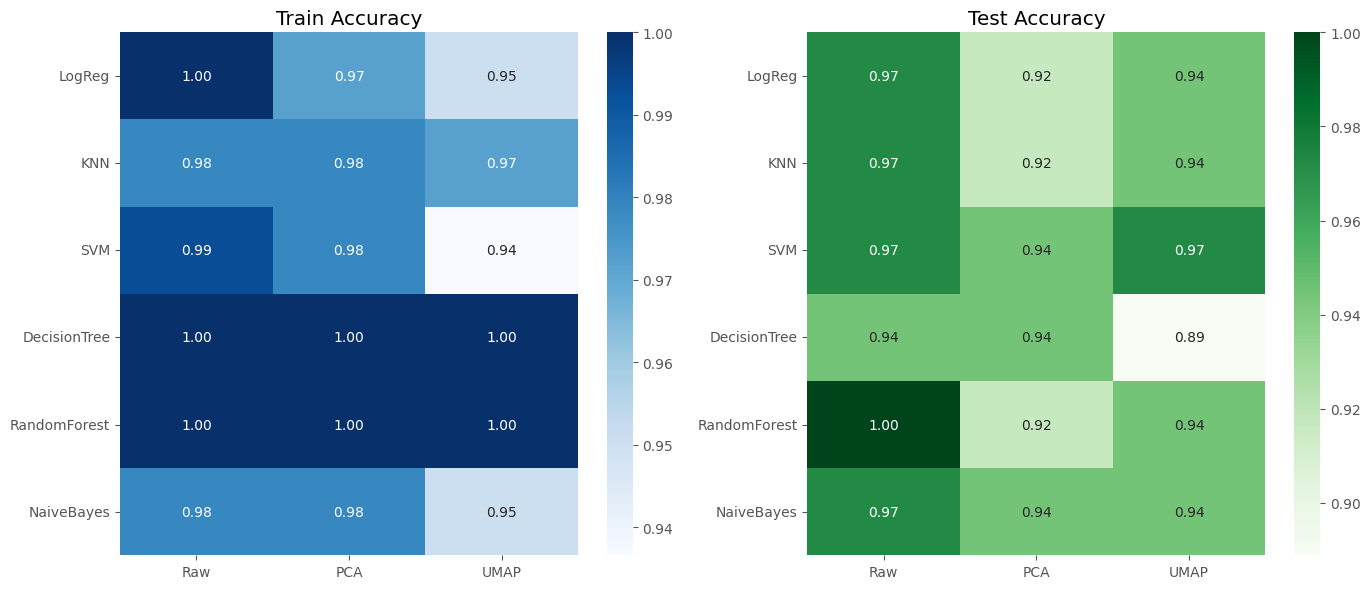

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(train_df, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Train Accuracy")

sns.heatmap(test_df, annot=True, fmt=".2f", cmap="Greens", ax=axes[1])
axes[1].set_title("Test Accuracy")

plt.tight_layout()
plt.show()

## Выводы по задаче 5.

Лучший результат показал SVM (UMAP): высокая точность на test без переобучения.
RandomForest идеален на train, но немного проседает → есть переобучение.
На исходных данных (Raw) точность чаще выше, так как сохраняется вся информация, а при PCA/UMAP возможна небольшая потеря признаков.

## Задание 6. Более пристальный анализ (3 балла)

Для лучшего алгоритма из предыдущего задания постройте `Classification Report`, `Confusion Matrix, Precision Recall Curve, ROC Curve.

Удалось ли обнаружить какие-то аномалии в работе нашего алгоритма? Можем ли мы принять полученные результаты?

In [26]:
best_model = SVC(probability=True)

best_model.fit(X_train_umap, y_train)

y_pred = best_model.predict(X_test_umap)
y_proba = best_model.predict_proba(X_test_umap)

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.92      1.00      0.96        12
           2       1.00      0.93      0.96        14
           3       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



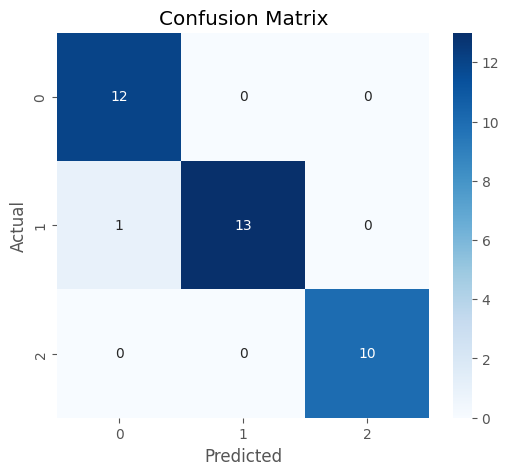

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

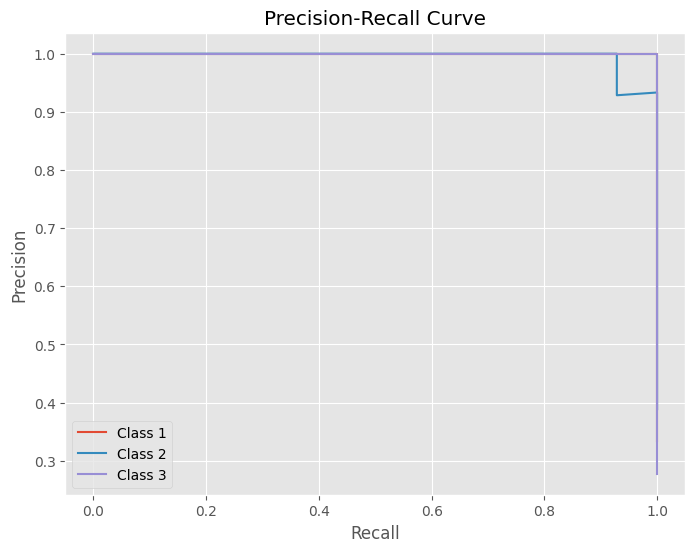

In [29]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])

plt.figure(figsize=(8, 6))

for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall, precision, label=f"Class {i+1}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

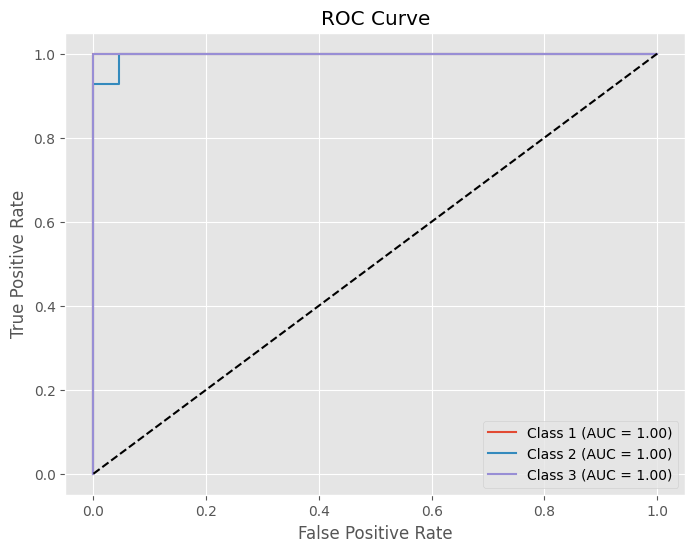

In [30]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i+1} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Выводы по задаче 6.

Модель показывает практически идеальную классификацию: все объекты распознаны правильно, кроме одного случая (1 ошибка между классами 1 и 0). Ошибки минимальны, классы хорошо разделимы. Аномалий не наблюдается, результаты можно считать надежными.

**Итоговый балл за домашнее задание = набранный балл / 2**